In [1]:
import sys

print(sys.version)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
# from tensorflow.keras.callbacks import LearningRateScheduler # A Keras callback
# We’ll pass our learning rate schedule to this class which 
# will be called as a callback at the completion of each epoch to calculate our learning rate
import numpy as np

# class LearningRate():
#     def __init__(self, epochs, initAlpha=0.01, factor=0.5, dropEvery=10):
# 		# store the base initial learning rate, drop factor, and
# 		# epochs to drop every
# 		self.initAlpha = initAlpha
# 		self.factor = factor
# 		self.dropEvery = dropEvery
	
#     def __call__(self, epoch):
# 		# compute the learning rate for the current epoch
# 		exp = np.floor((1 + epoch) / self.dropEvery)
# 		alpha = self.initAlpha * (self.factor ** exp)
# 		# return the learning rate
# 		return float(alpha)

def scheduler(epoch):
    # compute the learning rate for the current epoch
    dropEvery = 10
    initAlpha = 0.01
    factor = 0.5
    exp = np.floor((1 + epoch) / dropEvery)
    alpha = initAlpha * (factor ** exp)
    # return the learning rate
    print('lr =', alpha)
    return float(alpha)

    #TODO : stop the deacay (and the whole training after 20 .... lie in the paper)


In [ ]:
! pip install np_utils

In [3]:
import numpy as np
import scipy as sp 

from IPython.display import display
from matplotlib import pyplot as plt
import matplotlib as mpl

import tensorflow as tf
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.layers import Conv2D, MaxPooling2D # TODO - is this import realy neccessary? it recognize 1D pooling withouy it
from keras.layers import BatchNormalization
#from keras.utils.visualize_util import plot
from keras.utils import plot_model
#from keras import utils
from keras import regularizers

#from DeepCNN_Functions import scheduler#LearningRate #TODO - a better way?

# def learning_rate_func(initAlpha=0.01, factor=0.5, dropEvery=10,epoch):
#     # compute the learning rate for the current epoch:
#     exp = np.floor((1 + epoch)/self.dropEvery)
# 	alpha = self.initAlpha*(self.factor**exp) 
#     return float(alpha)

## 1) Import the data set:

In [4]:
from scipy.io import loadmat 
DataBase = loadmat('16PQDs_480_NoNoise.mat')
X = [None]
Y = [None]

# 480 * 16 - 1
for i in range (0,7679): #TODO - make parametric..
#for keys in DataBase
    #temp = DataBase ['SignalsDataBase'][0][i]['signals']
    X.append(DataBase ['SignalsDataBase'][0][i]['signals'][0])
    Y.append(DataBase ['SignalsDataBase'][0][i]['labels'][0])

#(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = np.array(X[1:7000])

X_train = np.expand_dims(X_train,axis=-1)
numOfFeatures = X_train.shape[1]

Y_train = np.reshape( np.array(Y[1:7000]) , (6999,1) )
X_validate = np.array(X[7000:len(X)])

X_validate = np.expand_dims(X_validate,axis=-1)

Y_validate =  np.reshape( np.array(Y[7000:len(Y)]) ,(680,1) )

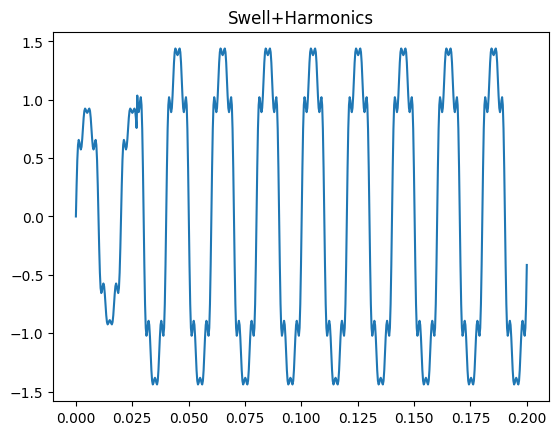

In [5]:
t = np.linspace(0,0.2,640)
plt.plot(t,X[9])
plt.title(Y[9])
plt.show()

## 2) Normalize the data and Onehot encoding

In [6]:
# Make OneHot classes :
from sklearn.preprocessing import OneHotEncoder#,LabelEncoder
OHE = OneHotEncoder()
#y_test_OneHot = OHE.fit_transform(y_test).toarray()
Y_train_OneHot = OHE.fit_transform(Y_train).toarray()
Y_validate_OneHot = OHE.fit_transform(Y_validate).toarray()

## 3) Train a Deep convolutional neural network

In [7]:
# Build the CNN model :
model = keras.models.Sequential()
#TODO : how to write model = Sequential instead

#add model layers:
# UNIT1 #############################################
# input_shape=(numOfFeatures,1)

# Conv1:
model.add(keras.layers.Conv1D(filters = 32, kernel_size=3, strides = 1, activation='relu'))
# Conv2:
model.add(keras.layers.Conv1D(filters = 32, kernel_size=3, strides = 1, activation='relu'))
# Pool1:
model.add(keras.layers.MaxPool1D(pool_size=(3), strides = 1)) #TODO : data_format='channels_first' ??
# BN1:
model.add(keras.layers.BatchNormalization())
# UNIT2 #####################################
# Conv3:
model.add(keras.layers.Conv1D(filters = 64, kernel_size=3,strides = 1, activation='relu'))
# Conv4:
model.add(keras.layers.Conv1D(filters = 64, kernel_size=3,strides = 1, activation='relu'))
# Pool2:
model.add(keras.layers.MaxPool1D(pool_size=(3), strides = 1)) #TODO : data_format='channels_first' ??
# BN2:
model.add(keras.layers.BatchNormalization())
# UNIT3 ####################################
# Conv5:
model.add(keras.layers.Conv1D(filters = 128, kernel_size=3,strides = 1, activation='relu'))
# Conv6:
model.add(keras.layers.Conv1D(filters = 128, kernel_size=3,strides = 1, activation='relu'))
# Pool3:
model.add(keras.layers.GlobalMaxPooling1D()) #TODO : data_format='channels_first' ??
# BN4:
model.add(keras.layers.BatchNormalization())

# Fully Connected Part ####################################

model.add(tf.keras.layers.Flatten()) 
# Dense1:
model.add(keras.layers.Dense(units=256, activation='relu',use_bias=True))
# Dense2:
model.add(keras.layers.Dense(units=128, activation='relu',use_bias=True))
# BN3:
model.add(keras.layers.BatchNormalization())
# Dense3:
model.add(keras.layers.Dense(units=16, activation='softmax',use_bias=True)) #TODO : kernel_regularizer=regularizers.l2(0.1) ?

# training parameters:

callback = tf.keras.callbacks.LearningRateScheduler(scheduler)

In [8]:
model.compile(  loss        = 'categorical_crossentropy',
                optimizer   = 'nadam',
                metrics     = ['accuracy']   
             )

In [9]:
# Train the model:
model_history = model.fit(X_train, Y_train_OneHot, 
                        batch_size = 64,
                        epochs=43 , 
                        callbacks=[callback],
                        validation_data=(X_validate, Y_validate_OneHot),
                        verbose=1)

lr = 0.01
Epoch 1/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.6568 - loss: 0.8728 - val_accuracy: 0.0632 - val_loss: 22.0075 - learning_rate: 0.0100
lr = 0.01
Epoch 2/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.7620 - loss: 0.5733 - val_accuracy: 0.0794 - val_loss: 22.2271 - learning_rate: 0.0100
lr = 0.01
Epoch 3/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.7793 - loss: 0.5240 - val_accuracy: 0.1912 - val_loss: 10.3402 - learning_rate: 0.0100
lr = 0.01
Epoch 4/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.7787 - loss: 0.5201 - val_accuracy: 0.0971 - val_loss: 19.7805 - learning_rate: 0.0100
lr = 0.01
Epoch 5/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.8015 - loss: 0.4573 - val_accuracy: 0.1368 - val_loss: 11.2335 - learning_rate: 0.0100
lr = 0.01
Epoch 6/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.8113 - loss: 0.4292 - val_accuracy: 0.1574 - val_loss: 10.5938 - learning_rate: 0.0100
lr = 0.01
Epoch

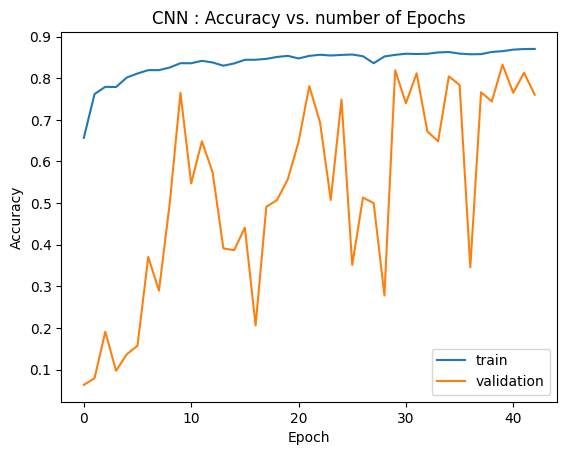

In [10]:
# Plot CNN's accuracy vs. epoch num:
fig = plt.figure()
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN : Accuracy vs. number of Epochs')
plt.legend(['train','validation'])
plt.show()

In [11]:
# serialize model to JSON
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)
    
# serialize weights to HDF5
model.save_weights("_MiniBatch_lr_db480_NoNoise.weights.h5")
print("Saved model to disk")

Saved model to disk


## Inference

In [12]:
# load json and create model:
json_file = open('model.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = tf.keras.models.model_from_json(loaded_model_json)

# load weights into new model:
loaded_model.load_weights("_MiniBatch_lr_db480_NoNoise.weights.h5")
print("Loaded model from disk")

# evaluate loaded model on test data

loaded_model.compile(loss        = 'categorical_crossentropy',
                    optimizer   = 'nadam',
                    metrics     = ['accuracy']   
                    )

score = loaded_model.evaluate(X_validate, Y_validate_OneHot, verbose=0)
print("%s: %.2f%%" % (loaded_model.metrics_names[1], score[1]*100))

Loaded model from disk
compile_metrics: 76.03%


## Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
Prediction: Swell+Harmonics , Label: Swell+Harmonics 
DeepCNN prediction is True


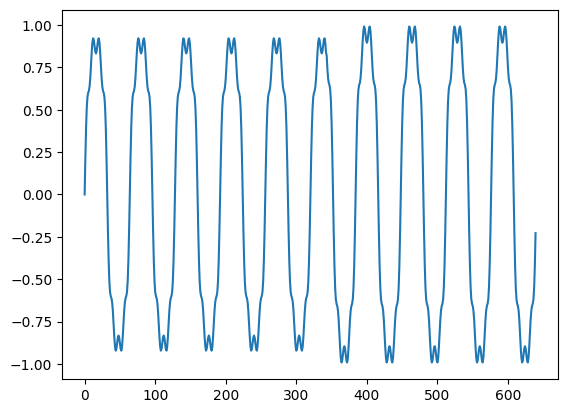

In [13]:
# Given a signal with a disturb 
Xtest = np.array(X_validate[62:63])
Ytest = Y_validate[62:63]
#Xtest = np.expand_dims(Xtest,axis=-1)

XtestPredict = np.round(loaded_model.predict(Xtest))
Xtest_label = OHE.inverse_transform(XtestPredict)[0][0]
verdict = (Xtest_label == Ytest[0])
print("Prediction:", Xtest_label , ", Label:" , Ytest[0][0],"\nDeepCNN prediction is",verdict[0])

plt.plot(Xtest[0])
plt.show()

In [ ]:
# Assume 'model' is your compiled and trained Keras model
# Assume 'x_test' and 'y_test' are your test features and labels

print("Evaluating model on test data...")
results = model.evaluate(X_validate, Y_validate_OneHot, batch_size=64, verbose=1)

# The 'results' variable contains the loss and metric values
# The order corresponds to model.metrics_names
print("Test Loss:", results[0])
print("Test Accuracy:", results[1]) # Assuming accuracy was the first metric specified

# Alternatively, if you compiled with named metrics:
# results_dict = model.evaluate(x_test, y_test, return_dict=True)
# print(results_dict)

In [ ]:
loaded_model.metrics_names